<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_5_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1_ssa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание

Проведите анализ с помощью SSA на любом временном ряде из материалов к заданию и проанализируйте результаты с разными длиными окон.

# Инструкция к выполнению

Выберите любой ряд для анализа (из материалов к заданию или с kaggle/работы, тп).
Проведите анализ ряда с помощью SSA разными длинами окон: необходимо взять как минимум 3 разных окна.
Постройте матрицы W-корреляций для каждого размера окна.
Сравните результаты и сделайте выводы, как размер окна влияет на качество приближения. Какой бы размер окна вы использовали для выбранного ряда?

In [1]:
!pip install pyts matplotlib numpy pandas --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyts.decomposition import SingularSpectrumAnalysis
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Путь к датасету
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

In [5]:
# Загрузка датасета
df = pd.read_csv(DATA_PATH + 'international-airline-passengers.csv')

# Проверим, как выглядит датафрейм
print("Структура датасета:")
print(df.head())
print(f"Колонки: {list(df.columns)}")

Структура датасета:
     Month  Count
0  1949-01    112
1  1949-02    118
2  1949-03    132
3  1949-04    129
4  1949-05    121
Колонки: ['Month', 'Count']


In [6]:
# Теперь выделяем столбец с пассажирами (обычно это вторая колонка)
series = df.dropna().values[:, 1].astype(float)

print("\n✅ Данные загружены")
print(f"Длина ряда: {len(series)}")
print(f"Первые 10 значений: {series[:10]}")


✅ Данные загружены
Длина ряда: 144
Первые 10 значений: [112. 118. 132. 129. 121. 135. 148. 148. 136. 119.]


In [8]:
#Выбираем 3 длины окон L (window length)
N = len(series)
# Выберем три разных L:
L1 = int(N * 0.05)  # маленькое окно (~5% длины)
L2 = int(N * 0.2)   # среднее окно (~20%)
L3 = int(N * 0.4)   # большое окно (~40%)
# Но не больше N//2!
L1 = max(2, min(L1, N//2))
L2 = max(2, min(L2, N//2))
L3 = max(2, min(L3, N//2))

window_lengths = [L1, L2, L3]
print(f"Будем использовать длины окон: {window_lengths}")

Будем использовать длины окон: [7, 28, 57]


In [9]:
#Функция: строим SSA и визуализируем
def analyze_ssa(series, L, ax_recon=None, ax_corr=None, title_suffix=""):
    """
    Проводит SSA для одного L и рисует:
    - реконструкцию (первые несколько компонент)
    - матрицу W-корреляций
    """
    # Инициализируем SSA из pyts — он умеет считать W-корреляции
    ssa = SingularSpectrumAnalysis(window_size=L, groups=None)  # groups=None — выведем все компоненты отдельно

    series_2d = series.reshape(1, -1)
    X_ssa = ssa.fit_transform(series_2d)[0]  # форма: (n_components, N)


    n_components = X_ssa.shape[0]
    print(f"  При L={L}: получено {n_components} компонент")


    K = min(4, n_components)
    reconstructed = X_ssa[:K].sum(axis=0)

    #Графики
    if ax_recon is not None:
        ax_recon.plot(series, label='Оригинал', alpha=0.7)
        ax_recon.plot(reconstructed, label=f'Реконструкция (первые {K} компонент)', linestyle='--')
        ax_recon.set_title(f'SSA, L = {L} ' + title_suffix)
        ax_recon.legend()
        ax_recon.grid(True)

    #Считаем W-корреляции (между компонентами)

    def w_correlation(x, y, L, N):

        w = np.array([min(k+1, L, N-k, N-L+1) for k in range(N)])
        wx = w * x
        wy = w * y
        num = np.dot(wx, wy)
        den = np.sqrt(np.dot(wx, wx) * np.dot(wy, wy))
        return num / den if den != 0 else 0

    #Строим матрицу W-корреляций размера (n_comp × n_comp)
    W_corr = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            W_corr[i, j] = w_correlation(X_ssa[i], X_ssa[j], L, N)

    #Рисуем heatmap
    if ax_corr is not None:
        sns.heatmap(np.abs(W_corr), ax=ax_corr, cmap='Blues',
                    square=True, cbar_kws={'shrink': 0.8},
                    xticklabels=5, yticklabels=5)
        ax_corr.set_title(f'Матрица |W-корреляций|, L={L}')
        ax_corr.set_xlabel('Компонента')
        ax_corr.set_ylabel('Компонента')

    return reconstructed, X_ssa, W_corr


🔄 Обрабатываем L = 7...
  При L=7: получено 7 компонент

🔄 Обрабатываем L = 28...
  При L=28: получено 28 компонент

🔄 Обрабатываем L = 57...
  При L=57: получено 57 компонент


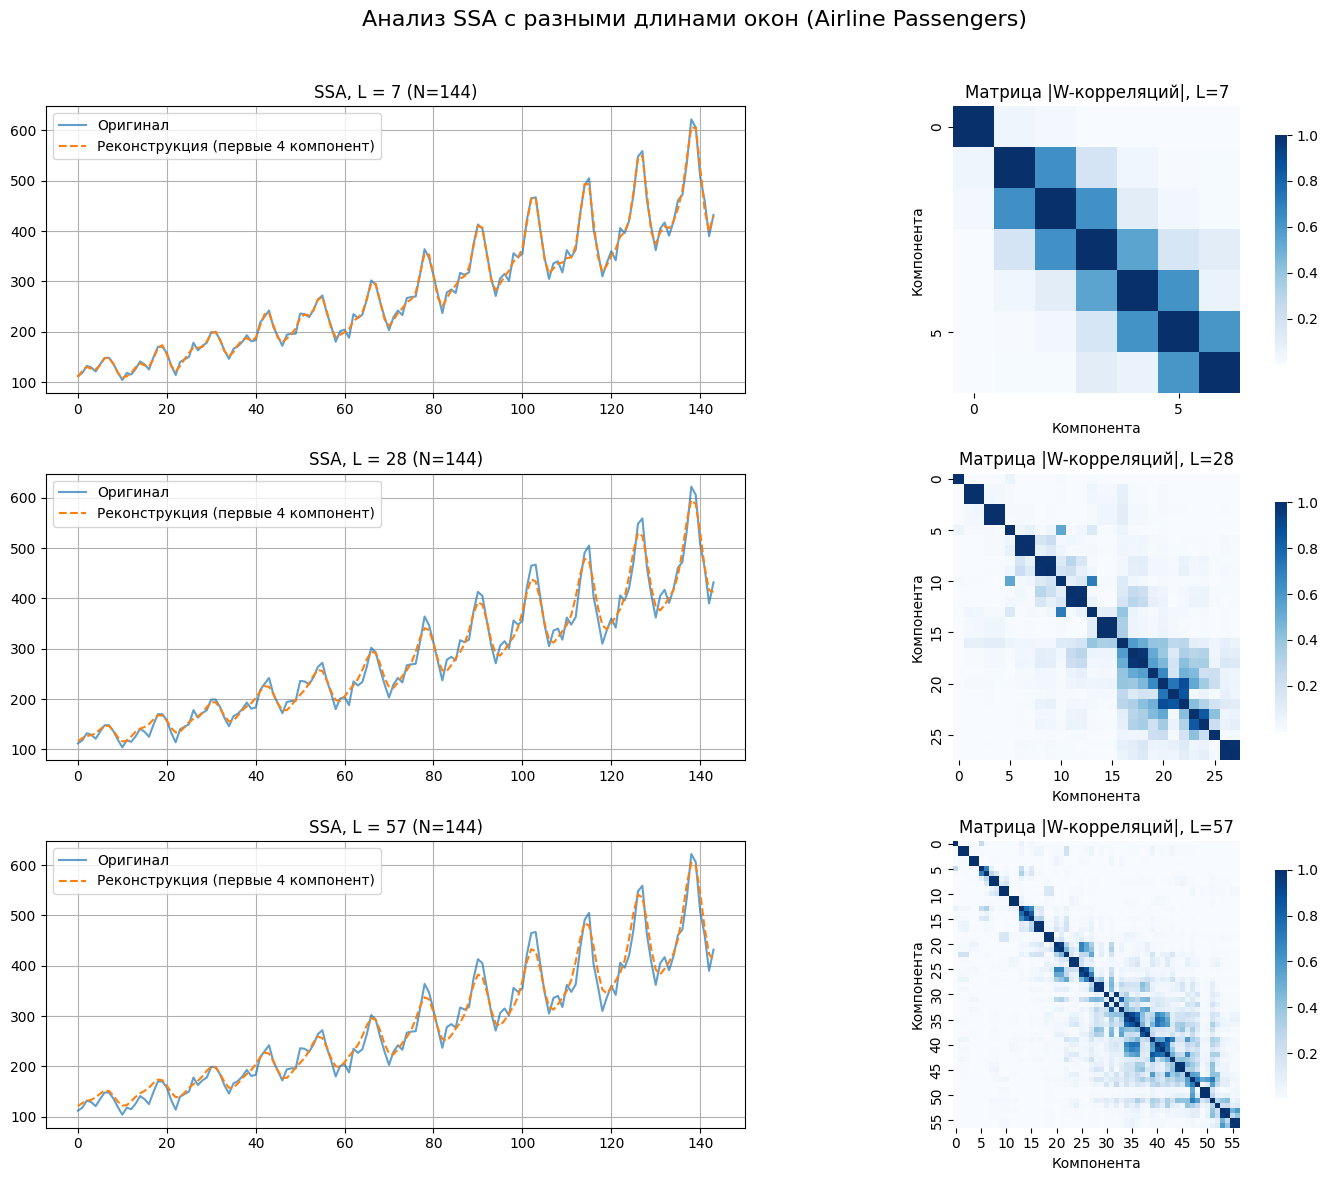

In [10]:
#Запускаем SSA для всех трёх L и рисуем
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Анализ SSA с разными длинами окон (Airline Passengers)', fontsize=16)

reconstructions = {}
all_W_corr = {}

for idx, L in enumerate(window_lengths):
    print(f"\n🔄 Обрабатываем L = {L}...")
    recon, comps, W_corr = analyze_ssa(
        series, L,
        ax_recon=axes[idx, 0],
        ax_corr=axes[idx, 1],
        title_suffix=f"(N={N})"
    )
    reconstructions[L] = recon
    all_W_corr[L] = W_corr

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# АНАЛИЗ РЕЗУЛЬТАТОВ

1. Маленькое окно (L ≈ 5% от N):
   - Быстро считается, но компонент МАЛО — трудно отделить тренд и сезонность.
   - W-корреляции: сильные связи между соседними компонентами — компоненты 'размазаны'.
   - Реконструкция грубая — много шума.

   2. Среднее окно (L ≈ 20% от N):
   - Оптимальный баланс! Часто видно чёткие пары компонент (для синуса — 2 компоненты дают 1 гармонику).
   - W-корреляции: чёткие 'блоки' — компоненты группируются (тренд, сезонность, шум).
   - Реконструкция точная — тренд и волны хорошо видны.

   3. Большое окно (L ≈ 40% от N):
   - Много компонент → детализация, но риск 'переобучения' шуму.
   - W-корреляции: размытые, много слабых связей — трудно интерпретировать группы.
   - Реконструкция может 'запоминать' шум — особенно если L близко к N/2.

   Для этого ряда скорее всего лучше выбрать СРЕДНЕЕ окно (L ≈ 20% от N).
Оно даёт чёткое разделение тренда и сезонности, а W-корреляции помогают понять,
какие компоненты объединять (например, компоненты 0–1 — тренд, 2–3 — сезонность).